In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
data_path = '/content/drive/MyDrive/Colab Notebooks/titanic.csv'

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

data = pd.read_csv(data_path, index_col='PassengerId')
data = data.drop(columns = ['Name','Ticket'])
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
PassengerId,,,,,,,,,
1,0,3,male,22.0,1,0,7.2500,NaN,S
2,1,1,female,38.0,1,0,71.2833,C85,C
3,1,3,female,26.0,0,0,7.9250,NaN,S
4,1,1,female,35.0,1,0,53.1000,C123,S
5,0,3,male,35.0,0,0,8.0500,NaN,S


In [12]:
X = data.drop('Survived', axis=1)
y = data['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=.8, shuffle=True)
titanic_data=X_train
titanic_data['Survived']=y_train
titanic_test=X_test
titanic_test['Survived']=y_test

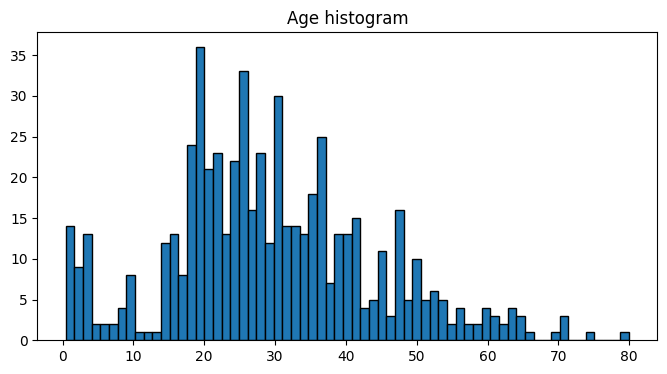

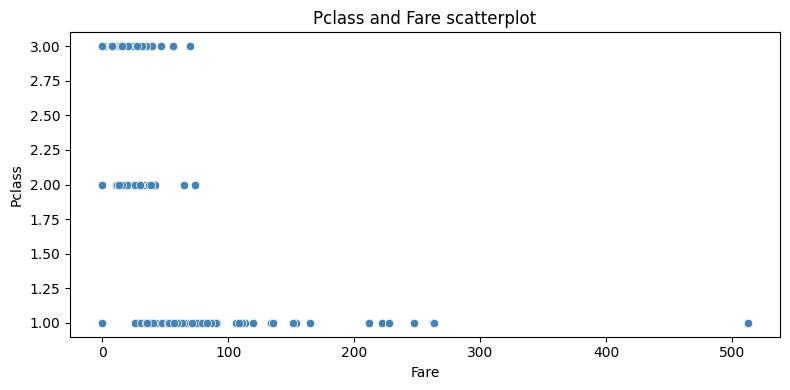

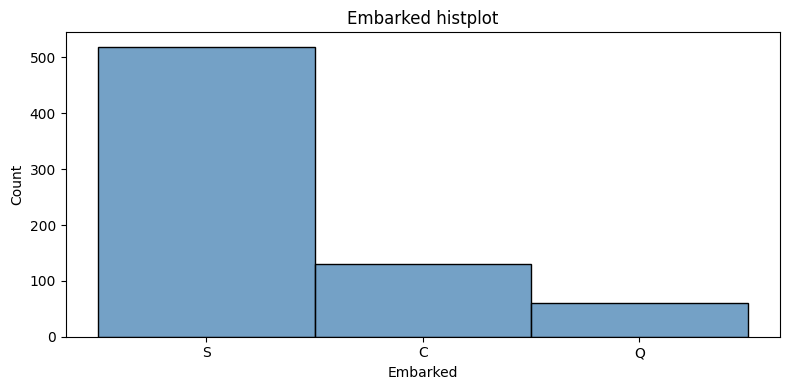

In [13]:
plt.figure(figsize=(8, 4))
plt.title('Age histogram')
plt.hist(titanic_data['Age'], edgecolor='black', bins=65)

plt.figure(figsize=(8, 4))
plt.title('Pclass and Fare scatterplot')
sns.scatterplot(titanic_data, x='Fare', y='Pclass', color='steelblue')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.title('Embarked histplot')
sns.histplot(titanic_data, x='Embarked', color='steelblue')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8, 4))
plt.title('Age histogram')
plt.hist(titanic_data['Age'], edgecolor='black', bins=65)

plt.figure(figsize=(8, 4))
plt.title('Parch histogram')
plt.hist(titanic_data['Parch'], edgecolor='black', bins=20)

plt.figure(figsize=(8, 4))
plt.title('Sib histogram')
plt.hist(titanic_data['SibSp'], edgecolor='black', bins=20)

plt.figure(figsize=(8, 4))
plt.title('Age and Fare scatterplot')
sns.scatterplot(titanic_data, x='Age', y='Fare', color='steelblue')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.title('Fare histogram')
plt.hist(titanic_data['Fare'], edgecolor='black', bins=120)

plt.figure(figsize=(8, 4))
plt.title('Pclass histogram')
plt.hist(titanic_data['Pclass'], edgecolor='black', bins=10)

plt.figure(figsize=(8, 4))
plt.title('Survived od Sex')
sns.barplot(titanic_data, x='Sex', y='Survived', color='steelblue')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.title('Fare and Survived scatterplot')
sns.boxplot(titanic_data, x='Survived', y='Fare', color='steelblue')
plt.tight_layout()
plt.show()

corr_matrix = titanic_data.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [14]:
np.random.seed(42)
moda = titanic_data.Embarked.mode()[0]
def uzupelnij(tabela):
  df=tabela
  age_prob = df['Age'].value_counts(normalize=True)
  missing_age = df['Age'].isna()
  df.loc[missing_age,'Age']=np.random.choice(age_prob.index, size=missing_age.sum(), p=age_prob.values)

  for pclass in df['Pclass'].unique():
      missing_pclass = df['Fare'].isna() & (df['Pclass'] == pclass)

      if missing_pclass.sum() > 0:
          fare_prob_class = titanic_data[titanic_data['Pclass'] == pclass]['Fare'].value_counts(normalize=True)
          df.loc[missing_pclass, 'Fare'] = np.random.choice(
              fare_prob_class.index,
              size=missing_pclass.sum(),
              p=fare_prob_class.values)

  df['Embarked']=df['Embarked'].fillna(moda)
  df = pd.get_dummies(data=df, columns=['Embarked'], dtype=bool)

  df['Cabin']=df['Cabin'].fillna(0)
  df.loc[df.Cabin !=0,'Cabin'] = 1

  df['Adult'] = 0
  df.loc[df.Age >= 18, 'Adult'] = 1
  df['Adult'] = df['Adult'].astype(bool)

  family_count = lambda x: x['Parch'] + x['SibSp']
  df['Family'] = df.apply(family_count, axis=1)
  df.loc[:,'SibSp':'Family']
  df.head()


  df.Sex=df['Sex'].map({'male': 0, 'female': 1})
  df['Cabin'] = df['Cabin'].astype(bool)
  df['Pclass'] = df['Pclass'].astype(np.int8)
  df['Sex'] = df['Sex'].astype(bool)
  df['Survived'] = df['Survived'].astype(bool)

  return df


titanic_data=uzupelnij(titanic_data)
titanic_test=uzupelnij(titanic_test)
titanic_data.isna().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Cabin,0
Survived,0
Embarked_C,0
Embarked_Q,0


In [15]:
print(titanic_data.head())
titanic_test.head()

             Pclass    Sex   Age  SibSp  Parch      Fare  Cabin  Survived  \
PassengerId                                                                 
661               1  False  50.0      2      0  133.6500  False      True   
600               1  False  49.0      1      0   56.9292   True      True   
48                3   True  27.0      0      0    7.7500  False      True   
630               3  False  57.0      0      0    7.7333  False     False   
93                1  False  46.0      1      0   61.1750   True     False   

             Embarked_C  Embarked_Q  Embarked_S  Adult  Family  
PassengerId                                                     
661               False       False        True   True       2  
600                True       False       False   True       1  
48                False        True       False   True       0  
630               False        True       False   True       0  
93                False       False        True   True       1  


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Survived,Embarked_C,Embarked_Q,Embarked_S,Adult,Family
PassengerId,,,,,,,,,,,,,
829,3,False,25.0,0,0,7.7500,False,True,False,True,False,True,0
251,3,False,22.0,0,0,14.4542,False,False,False,False,True,True,0
729,2,False,25.0,1,0,26.0000,False,False,False,False,True,True,1
617,3,False,34.0,1,1,14.4000,False,False,False,False,True,True,2
674,2,False,31.0,0,0,73.5000,False,True,False,False,True,True,0


In [16]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
def skaluj(df):
  df['Fare_robust'] = scaler.fit_transform(df[['Fare']])
  return df
titanic_data=skaluj(titanic_data)
titanic_test=skaluj(titanic_test)
print(titanic_data[['Fare', 'Fare_robust']].head())

                 Fare  Fare_robust
PassengerId                       
661          133.6500     5.098369
600           56.9292     1.816786
48             7.7500    -0.286759
630            7.7333    -0.287473
93            61.1750     1.998392


In [47]:
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, classification_report
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate

y_train=titanic_data['Survived']
X_train=titanic_data.drop(columns=['Survived'])
y_test=titanic_test['Survived']
X_test=titanic_test.drop(columns=['Survived'])

X=pd.concat([X_train, X_test])
y=pd.concat([y_train,y_test])

def metryki(model):
  model.fit(X_train, y_train) # uczenie
  y_pred = model.predict(X_test)
  print(classification_report(y_test, y_pred))
  confusion_matrix(y_test, y_pred)
  scoring=['f1', 'recall', 'precision']
  wyniki = cross_validate(model, X, y, scoring=scoring, cv=5)
  for metryka in scoring:
      srednia = wyniki[f'test_{metryka}'].mean()
      odchylenie = wyniki[f'test_{metryka}'].std()
      print(f"{metryka} — średnia: {srednia:.3f}, odchylenie: {odchylenie:.3f}")
  return

print("Dummy:")
model1 = DummyClassifier(strategy = 'uniform')
metryki(model1)


Dummy:
              precision    recall  f1-score   support

       False       0.63      0.53      0.58       113
        True       0.37      0.47      0.41        66

    accuracy                           0.51       179
   macro avg       0.50      0.50      0.50       179
weighted avg       0.53      0.51      0.52       179

f1 — średnia: 0.441, odchylenie: 0.017
recall — średnia: 0.517, odchylenie: 0.029
precision — średnia: 0.385, odchylenie: 0.020


najlepsze ustawienia: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 3}
wynik kroswalidacji:  0.816
wynik na tescie:      0.81


<Axes: xlabel='param_max_depth', ylabel='mean_test_score'>

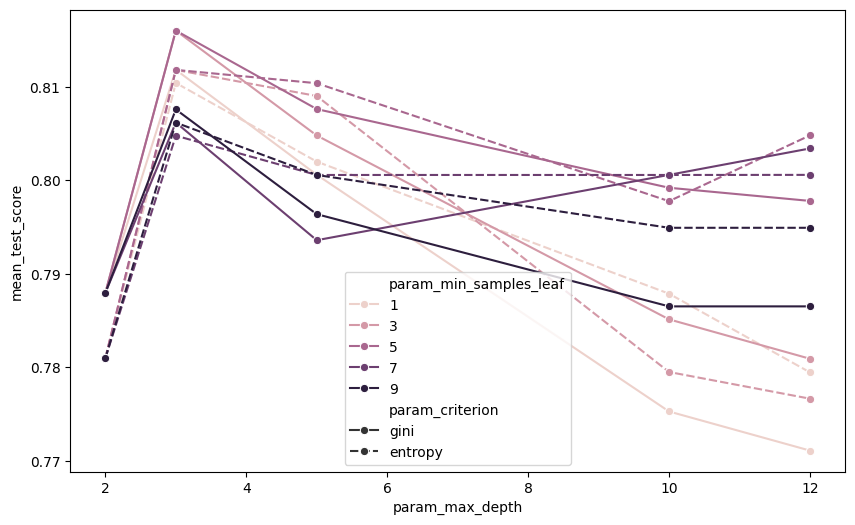

In [86]:
from sklearn.model_selection import GridSearchCV

# Siatka: kazdy klucz to nazwa hiperparametru, kazda lista to wartosci do sprawdzenia
siatka = {
    'max_depth':         [2, 3, 5, 10, 12, None],
    'criterion':         ['gini', 'entropy'],
    'min_samples_leaf':  [1, 3, 5, 7, 9],
}

szukaj = GridSearchCV(
    DecisionTreeClassifier(random_state=0),
    siatka,
    cv=5,
    scoring='accuracy'
)
szukaj.fit(X_train, y_train)

print("najlepsze ustawienia:", szukaj.best_params_)
print("wynik kroswalidacji: ", round(szukaj.best_score_, 3))
print("wynik na tescie:     ", round(szukaj.score(X_test, y_test), 3))

wyniki_df = pd.DataFrame(szukaj.cv_results_)
plt.figure(figsize=(10, 6))
wyniki_df
sns.lineplot(
    data=wyniki_df,
    x='param_max_depth',
    y='mean_test_score',
    style='param_criterion',
    hue='param_min_samples_leaf',
    marker='o'
)

Najlepszymi parametrami są max_depth = 3, drzewo ma max 8 liści i nie uczy się na pamięć wyników, min_samples_leaf = 3, liść musi mieć 3 osoby które miały tą decyzję, to znaczy, że nie przykłada takiej dużej wagi na outliery tylko szuka ogólnych zasad.

In [50]:
model2 = DecisionTreeClassifier(
    max_depth=szukaj.best_params_['max_depth'],
    criterion=szukaj.best_params_['criterion'],
    min_samples_leaf=szukaj.best_params_['min_samples_leaf']
    )

print("Tree:")
metryki(model2)

Tree:
              precision    recall  f1-score   support

       False       0.82      0.90      0.86       113
        True       0.80      0.65      0.72        66

    accuracy                           0.81       179
   macro avg       0.81      0.78      0.79       179
weighted avg       0.81      0.81      0.81       179

f1 — średnia: 0.720, odchylenie: 0.051
recall — średnia: 0.655, odchylenie: 0.090
precision — średnia: 0.810, odchylenie: 0.017


najlepsze ustawienia: {'metric': 'cosine', 'n_neighbors': 5, 'weights': 'distance'}
wynik kroswalidacji:  0.715
wynik na tescie:      0.754


<Axes: xlabel='param_n_neighbors', ylabel='mean_test_score'>

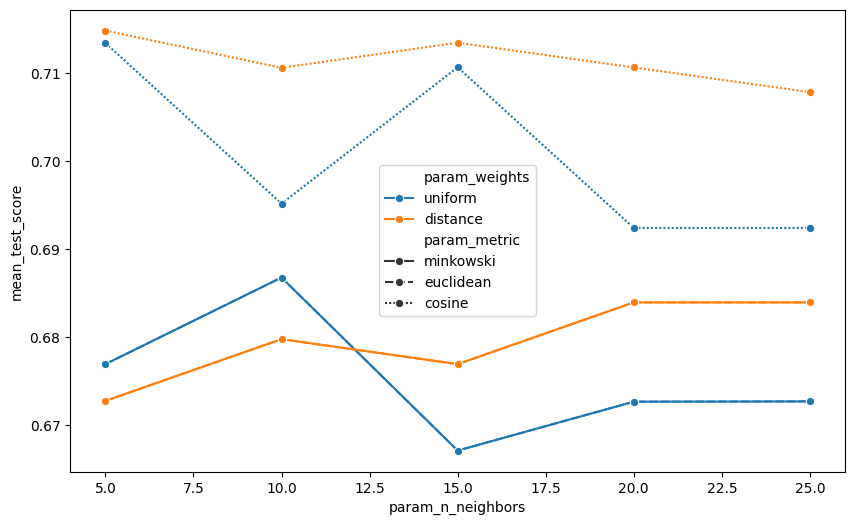

In [87]:
siatka = {
    'metric':       ['minkowski', 'euclidean','cosine'],
    'n_neighbors':  [5, 10, 15, 20 ,25],
    'weights':      ['uniform','distance']
}
szukaj = GridSearchCV(
    KNeighborsClassifier(),
    siatka,
    cv=5,
    scoring='accuracy'
)
szukaj.fit(X_train, y_train)

print("najlepsze ustawienia:", szukaj.best_params_)
print("wynik kroswalidacji: ", round(szukaj.best_score_, 3))
print("wynik na tescie:     ", round(szukaj.score(X_test, y_test), 3))

wyniki_df = pd.DataFrame(szukaj.cv_results_)
plt.figure(figsize=(10, 6))
wyniki_df
sns.lineplot(
    data=wyniki_df,
    x='param_n_neighbors',
    y='mean_test_score',
    hue='param_weights',
    style='param_metric',
    marker='o'
)

Najlepsze okazały się 5 n_neighbours i metryka cosine, czyli model nie zwraca uwagi na skalę wartości zmiennych oraz tworzy małą lokalną granicę decyzyjną. Tak samo distance okazał się lepszy niż uniform, czyli knn przykłada większą wagę do bliższych sąsiadów.

In [52]:
model3 = KNeighborsClassifier(
    metric=szukaj.best_params_['metric'],
    algorithm=szukaj.best_params_['algorithm'],
    n_neighbors=szukaj.best_params_['n_neighbors'],
    weights=szukaj.best_params_['weights']
)
print("KNN:")
metryki(model3)

KNN:
              precision    recall  f1-score   support

       False       0.78      0.85      0.81       113
        True       0.70      0.59      0.64        66

    accuracy                           0.75       179
   macro avg       0.74      0.72      0.73       179
weighted avg       0.75      0.75      0.75       179

f1 — średnia: 0.629, odchylenie: 0.030
recall — średnia: 0.602, odchylenie: 0.036
precision — średnia: 0.660, odchylenie: 0.041


In [83]:

for nazwa, m in [
    ("\n----- \nDummy      \n-----\n", model1),
    ("\n------\nDrzewo     \n------\n", model2),
    ("\n----  \nKNN        \n----\n", model3),
]:
    w = cross_val_score(m, X, y, cv=5)
    print(f"{nazwa} średnia  : {w.mean():.3f} +/- {w.std():.3f}")

    wyniki = cross_validate(m, X, y, scoring=scoring, cv=5)
    for metryka in scoring:
        srednia = wyniki[f'test_{metryka}'].mean()
        odchylenie = wyniki[f'test_{metryka}'].std()
        print(f" {metryka:9s}: {srednia:.3f} +/- {odchylenie:.3f}")


----- 
Dummy      
-----
 średnia  : 0.512 +/- 0.009
 f1       : 0.425 +/- 0.039
 recall   : 0.503 +/- 0.050
 precision: 0.370 +/- 0.035

------
Drzewo     
------
 średnia  : 0.808 +/- 0.024
 f1       : 0.720 +/- 0.051
 recall   : 0.655 +/- 0.090
 precision: 0.810 +/- 0.017

----  
KNN        
----
 średnia  : 0.727 +/- 0.025
 f1       : 0.629 +/- 0.030
 recall   : 0.602 +/- 0.036
 precision: 0.660 +/- 0.041


DecisionTree poradził sobie lepiej niż KNN, ma najlepsze f1, recall i precision, ale ma największe odchylenie na f1 i recall przez co jest trochę niestabilny.

KNN jest bardziej stabilny, ale gorzej przewiduje wyniki niż Drzewo, ale i tak lepiej niż losowo.